<a href="https://colab.research.google.com/github/kyoseikamada/LLMComp/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")
import random
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [ ]:
class CFG:
    VER = 1
    AUTHOR = "takaito"
    COMPETITION = "atmacup17"
    DATA_PATH = Path("kaggle/input/atmacup17")
    SEED = 42
    N_SPLIT = 3
    TARGET_COL = "Recommended IND"
    TARGET_COL_CLASS_NUM = 2

In [ ]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
seed_everything(CFG.SEED)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/LLMComp')

In [ ]:
clothing_master_df = pd.read_csv(CFG.DATA_PATH / "clothing_master.csv")
train_df = pd.read_csv(CFG.DATA_PATH / "train.csv")
test_df = pd.read_csv(CFG.DATA_PATH / "test.csv")

In [ ]:
train_df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count
0,0,25,3-season skirt!,"Adorable, well-made skirt! lined and very slim...",5,1,4
1,0,39,Very cute,Love the asymmetrical hem. waist fit snugly as...,5,1,0
2,0,42,Beautiful! fruns small for typical retailer si...,I love this skirt! i wasn't sure about the mix...,5,1,5
3,0,45,NaN,I was really pleased with this skirt. the ligh...,5,1,9
4,0,57,"Unique, pretty asymmetric skirt",I saw this skirt in retailer several months ag...,5,1,1


In [ ]:
test_df.head()

,Clothing ID,Age,Title,Review Text,Positive Feedback Count
0,0,32,So happy i bought this skirt!,"I love this skirt. it does run a little small,...",0
1,0,34,Runs small,"Beautiful patterns and colors, but it sits ver...",0
2,0,37,Love the comfort of thi skirt,It is easily paired with a nice tip for work a...,0
3,0,39,Way too small,"This is a beautiful skirt, but runs very small...",10
4,0,39,NaN,I usually wear a size 8/10 and i needed a larg...,0


In [ ]:
clothing_master_df.head()

,Clothing ID,Division Name,Department Name,Class Name
0,0,General,Bottoms,Skirts
1,1,General,Bottoms,Pants
2,2,General,Tops,Sweaters
3,3,General,Dresses,Dresses
4,4,General,Dresses,Dresses


In [ ]:
train_df = train_df.merge(clothing_master_df, on="Clothing ID", how="left")
test_df = test_df.merge(clothing_master_df, on="Clothing ID", how="left")

In [ ]:
test_df.head()

,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,32,So happy i bought this skirt!,"I love this skirt. it does run a little small,...",0,General,Bottoms,Skirts
1,0,34,Runs small,"Beautiful patterns and colors, but it sits ver...",0,General,Bottoms,Skirts
2,0,37,Love the comfort of thi skirt,It is easily paired with a nice tip for work a...,0,General,Bottoms,Skirts
3,0,39,Way too small,"This is a beautiful skirt, but runs very small...",10,General,Bottoms,Skirts
4,0,39,NaN,I usually wear a size 8/10 and i needed a larg...,0,General,Bottoms,Skirts


In [ ]:
train_cols = train_df.columns
test_cols = test_df.columns
for col in train_cols:
    if col in test_cols:
        print("train&test:", col)
    else:
        print("train only:", col)

train&test: Clothing ID
train&test: Age
train&test: Title
train&test: Review Text
train only: Rating
train only: Recommended IND
train&test: Positive Feedback Count
train&test: Division Name
train&test: Department Name
train&test: Class Name


In [ ]:
numerical_features = ["Age", "Positive Feedback Count"]
categorical_features = ["Clothing ID", "Title", "Review Text", "Division Name", "Department Name", "Class Name"]

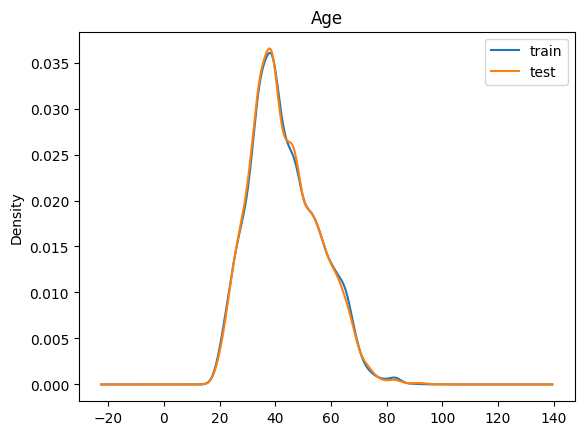

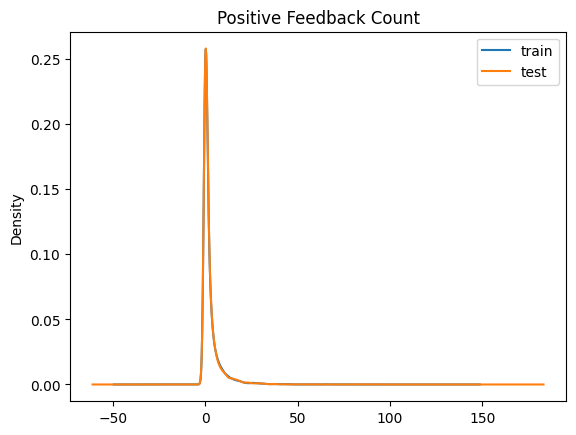

In [ ]:
for feature in numerical_features:
  plt.title(feature)
  train_df[feature].plot.kde(label="train")
  test_df[feature].plot.kde(label="test")
  plt.legend()
  plt.show()
  plt.close("all")

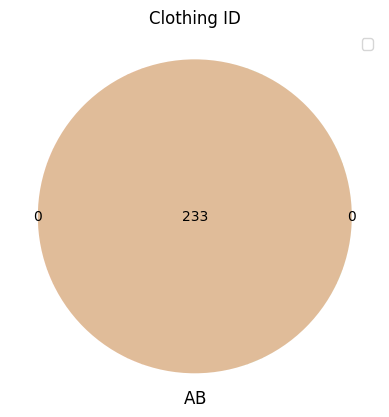

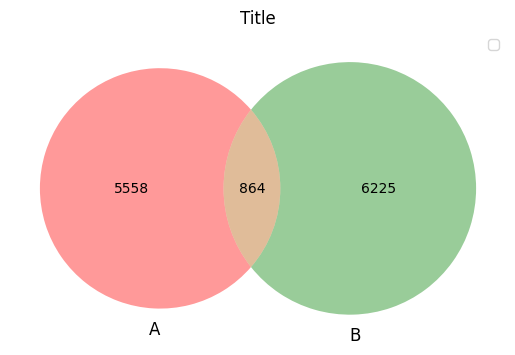

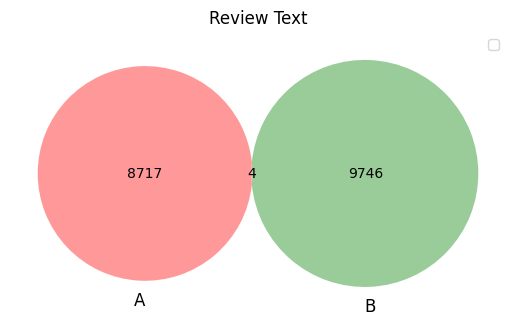

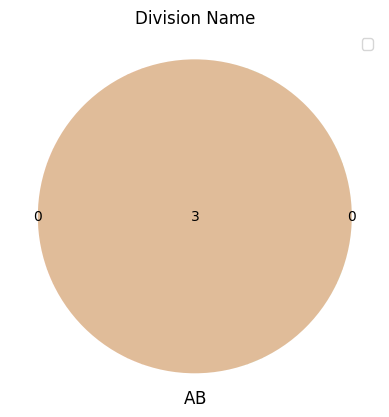

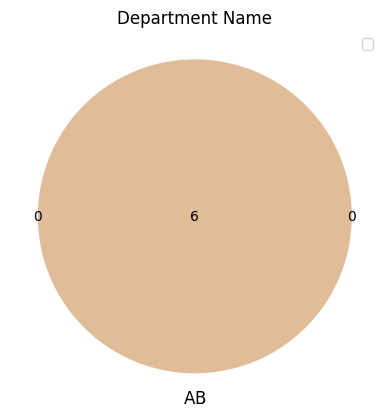

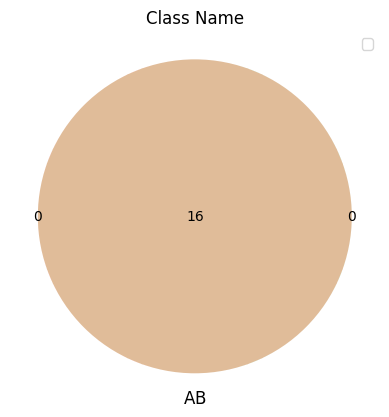

In [ ]:
for feature in categorical_features:
  plt.title(feature)
  venn2([set(train_df[feature]), set(test_df[feature])])
  plt.legend()
  plt.show()
  plt.close("all")

In [ ]:
kfold = StratifiedKFold(n_splits=CFG.N_SPLIT, shuffle=True, random_state=CFG.SEED)
for fold, (train_index, valid_index) in enumerate(kfold.split(train_df, train_df[CFG.TARGET_COL])):
  print("train: ", train_index[:10])
  print("valid: ", valid_index[:10])
  print(dict(train_df.iloc[valid_index][CFG.TARGET_COL].value_counts()))

train:  [ 0  1  2  4  7  8  9 10 11 12]
valid:  [ 3  5  6 18 20 22 24 28 31 32]
{1: np.int64(2734), 0: np.int64(600)}
train:  [ 0  1  3  5  6  7  9 10 12 14]
valid:  [ 2  4  8 11 13 19 25 26 27 29]
{1: np.int64(2734), 0: np.int64(599)}
train:  [ 2  3  4  5  6  8 11 13 18 19]
valid:  [ 0  1  7  9 10 12 14 15 16 17]
{1: np.int64(2734), 0: np.int64(599)}


# 単語の頻度情報を用いたモデル

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")
import random
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import lightgbm as lgb
import pickle

In [6]:
class CFG:
    VER = 1
    AUTHOR = "takaito"
    COMPETITION = "atmacup17"
    DATA_PATH = Path("kaggle/input/atmacup17")
    MODEL_NAME = "lightgbm"
    SEED = 42
    N_SPLIT = 3
    TARGET_COL = "Recommended IND"
    TARGET_COL_CLASS_NUM = 2
    METRIC = "auc"
    METRIC_MAXIMIZE_FLAG = True
    NUM_BOOST_ROUND = 10000
    EARLY_STOPPING_ROUND = 100
    VERBOSE = 250
    LGB_PARAMS= {
        "objective": "binary",
        "metric": "auc",
        "learning_rate": 0.01,
        "seed": SEED,
    }
    NGRAM_RANGE = (1, 2)
    LOWERCASE = True
    SUBLINEAR_TF = True
    MAX_DF = 0.8
    MIN_DF = 5
    SVD_DIM = 256
    PREFIX  = f"{AUTHOR}_{MODEL_NAME}_seed{SEED}_ver{VER}"

In [3]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
seed_everything(CFG.SEED)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

os.chdir('/content/drive/MyDrive/Colab Notebooks/LLMComp')

In [7]:
clothing_master_df = pd.read_csv(CFG.DATA_PATH / "clothing_master.csv")
train_df = pd.read_csv(CFG.DATA_PATH / "train.csv")
test_df = pd.read_csv(CFG.DATA_PATH / "test.csv")

In [8]:
train_df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count
0,0,25,3-season skirt!,"Adorable, well-made skirt! lined and very slim...",5,1,4
1,0,39,Very cute,Love the asymmetrical hem. waist fit snugly as...,5,1,0
2,0,42,Beautiful! fruns small for typical retailer si...,I love this skirt! i wasn't sure about the mix...,5,1,5
3,0,45,NaN,I was really pleased with this skirt. the ligh...,5,1,9
4,0,57,"Unique, pretty asymmetric skirt",I saw this skirt in retailer several months ag...,5,1,1


In [9]:
def make_text_column(df):
    df["text"] = df["Title"] + " " + df["Review Text"]
    return df

def preprocessing(df, clothing_master_df):
    df["Title"] = df["Title"].fillna("")
    df["Review Text"] = df["Review Text"].fillna("")
    df = df.merge(clothing_master_df, on="Clothing ID", how="left")
    df = make_text_column(df)
    return df

In [10]:
train_df = preprocessing(train_df, clothing_master_df)
test_df = preprocessing(test_df, clothing_master_df)

In [11]:
train_df.head()

,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,text
0,0,25,3-season skirt!,"Adorable, well-made skirt! lined and very slim...",5,1,4,General,Bottoms,Skirts,"3-season skirt! Adorable, well-made skirt! lin..."
1,0,39,Very cute,Love the asymmetrical hem. waist fit snugly as...,5,1,0,General,Bottoms,Skirts,Very cute Love the asymmetrical hem. waist fit...
2,0,42,Beautiful! fruns small for typical retailer si...,I love this skirt! i wasn't sure about the mix...,5,1,5,General,Bottoms,Skirts,Beautiful! fruns small for typical retailer si...
3,0,45,,I was really pleased with this skirt. the ligh...,5,1,9,General,Bottoms,Skirts,I was really pleased with this skirt. the lig...
4,0,57,"Unique, pretty asymmetric skirt",I saw this skirt in retailer several months ag...,5,1,1,General,Bottoms,Skirts,"Unique, pretty asymmetric skirt I saw this ski..."


In [12]:
test_df.head()

,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,text
0,0,32,So happy i bought this skirt!,"I love this skirt. it does run a little small,...",0,General,Bottoms,Skirts,So happy i bought this skirt! I love this skir...
1,0,34,Runs small,"Beautiful patterns and colors, but it sits ver...",0,General,Bottoms,Skirts,"Runs small Beautiful patterns and colors, but ..."
2,0,37,Love the comfort of thi skirt,It is easily paired with a nice tip for work a...,0,General,Bottoms,Skirts,Love the comfort of thi skirt It is easily pai...
3,0,39,Way too small,"This is a beautiful skirt, but runs very small...",10,General,Bottoms,Skirts,"Way too small This is a beautiful skirt, but r..."
4,0,39,,I usually wear a size 8/10 and i needed a larg...,0,General,Bottoms,Skirts,I usually wear a size 8/10 and i needed a lar...


In [13]:
vectorizer = TfidfVectorizer(ngram_range=CFG.NGRAM_RANGE,
                             lowercase=CFG.LOWERCASE,
                             sublinear_tf=CFG.SUBLINEAR_TF,
                             max_df=CFG.MAX_DF, min_df=CFG.MIN_DF
                            )

In [14]:
vectorizer.fit(train_df["text"])

TfidfVectorizer(max_df=0.8, min_df=5, ngram_range=(1, 2), sublinear_tf=True)

In [15]:
print(vectorizer.get_feature_names_out())
print(len(vectorizer.get_feature_names_out()))

['00' '00 and' '00 or' ... 'zippers' 'zipping' 'zips']
17705


In [16]:
train_tfidf_matrix = vectorizer.transform(train_df["text"])
test_tfidf_matrix = vectorizer.transform(test_df["text"])

In [17]:
train_tfidf_matrix.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [18]:
svd = TruncatedSVD(n_components=CFG.SVD_DIM, random_state=CFG.SEED)

In [19]:
svd.fit(train_tfidf_matrix)

TruncatedSVD(n_components=256, random_state=42)

In [20]:
train_tfidf_svd_matrix = svd.transform(train_tfidf_matrix)
test_tfidf_svd_matrix = svd.transform(test_tfidf_matrix)

In [21]:
print(train_tfidf_matrix.shape, train_tfidf_svd_matrix.shape)

(10000, 17705) (10000, 256)


In [22]:
def training_and_inference(train_df, test_df, train_matrix, test_matrix, ex_name="temp"):
    oof_predictions = np.zeros(len(train_df))
    test_predictions = np.zeros(len(test_df))
    kfold = StratifiedKFold(n_splits=CFG.N_SPLIT, shuffle=True, random_state=CFG.SEED)
    for fold, (train_index, valid_index) in enumerate(kfold.split(train_df, train_df[CFG.TARGET_COL])):
        print(f"training fold {fold+1}")
        x_train = train_matrix[train_index]
        y_train = train_df[CFG.TARGET_COL].iloc[train_index]
        x_valid = train_matrix[valid_index]
        y_valid = train_df[CFG.TARGET_COL].iloc[valid_index]
        model = lgb.train(
            params=CFG.LGB_PARAMS,
            train_set=lgb.Dataset(x_train, y_train),
            num_boost_round=CFG.NUM_BOOST_ROUND,
            valid_sets=[lgb.Dataset(x_train, y_train),
                        lgb.Dataset(x_valid, y_valid)],
            callbacks=[lgb.early_stopping(stopping_rounds=CFG.EARLY_STOPPING_ROUND, verbose=CFG.VERBOSE),
                       lgb.log_evaluation(CFG.VERBOSE)]
        )
        # 検証セットの推論
        valid_pred = model.predict(x_valid)
        oof_predictions[valid_index] = valid_pred
        # テストセットの推論
        test_pred = model.predict(test_matrix)
        test_predictions += test_pred / CFG.N_SPLIT
        pickle.dump(model, open(f"{ex_name}_fold{fold + 1}.pkl", "wb"))
    # 交差検証のスコアの確認
    print("CV Score: ", roc_auc_score(train_df[CFG.TARGET_COL], oof_predictions))
    # submission.csv の作成
    test_df["target"] = test_predictions
    test_df[["target"]].to_csv(f"{ex_name}_submission.csv", index=False)

In [23]:
# TF-IDF 行列を用いて学習 & 推論
training_and_inference(train_df,
                       test_df,
                       train_tfidf_matrix,
                       test_tfidf_matrix,
                       ex_name=f"TF-IDF_{CFG.PREFIX}")

training fold 1
[LightGBM] [Info] Number of positive: 5468, number of negative: 1198
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.536633 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 110879
[LightGBM] [Info] Number of data points in the train set: 6666, number of used features: 3492
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.820282 -> initscore=1.518259
[LightGBM] [Info] Start training from score 1.518259
Training until validation scores don't improve for 100 rounds
[250]	valid_0's auc: 0.966746	valid_1's auc: 0.898887
[500]	valid_0's auc: 0.987421	valid_1's auc: 0.919134
[750]	valid_0's auc: 0.993589	valid_1's auc: 0.925754
[1000]	valid_0's auc: 0.996012	valid_1's auc: 0.928421
[1250]	valid_0's auc: 0.997346	valid_1's auc: 0.929713
Early stopping, best iteration is:
[1334]	valid_0's auc: 0.9977	valid_1's auc: 0.92991
traini

In [24]:
# SVD で次元圧縮した行列を用いて学習 & 推論
training_and_inference(train_df,
                       test_df,
                       train_tfidf_svd_matrix,
                       test_tfidf_svd_matrix,
                       ex_name=f"SVD_{CFG.PREFIX}")

training fold 1
[LightGBM] [Info] Number of positive: 5468, number of negative: 1198
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.055455 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 65280
[LightGBM] [Info] Number of data points in the train set: 6666, number of used features: 256
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.820282 -> initscore=1.518259
[LightGBM] [Info] Start training from score 1.518259
Training until validation scores don't improve for 100 rounds
[250]	valid_0's auc: 0.97776	valid_1's auc: 0.903722
[500]	valid_0's auc: 0.993486	valid_1's auc: 0.914739
[750]	valid_0's auc: 0.996269	valid_1's auc: 0.919739
[1000]	valid_0's auc: 0.997944	valid_1's auc: 0.922469
[1250]	valid_0's auc: 0.998893	valid_1's auc: 0.922951
Early stopping, best iteration is:
[1155]	valid_0's auc: 0.998663	valid_1's auc: 0.923166
training fold 2
[LightGBM] [Info] Number of positive: 5468, number of 